In [1]:
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torchvision import transforms

In [2]:
transform = transforms.ToTensor()

train_ds = MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_ds = MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.01MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.88MB/s]


In [3]:
train_ds.train_data.shape, test_ds.test_data.shape

/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:81: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")


(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

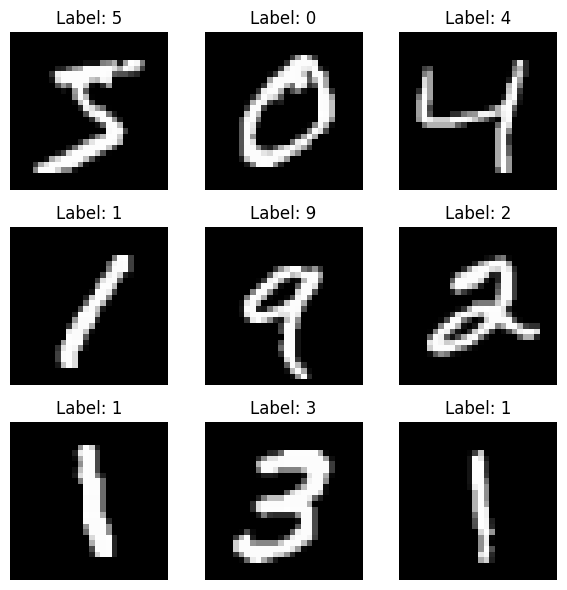

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(train_ds.data[i], cmap="gray")
    ax.set_title(f"Label: {train_ds.targets[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
from torch.utils.data import DataLoader, random_split

In [6]:
len(train_ds)*0.85, len(train_ds)*0.15

(51000.0, 9000.0)

In [7]:
batch_size = 64

train_size = int(0.85 * len(train_ds))
val_size = len(train_ds) - train_size
train_ds, val_ds = random_split(train_ds, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)
test_loader = DataLoader(test_ds, batch_size=batch_size)

In [8]:
import torch

In [9]:
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # 3,28,28 -> (6,28,28) : 28-5+2*2 + 1 = 28
            nn.Conv2d(1, 6, kernel_size=5,padding=2),
            nn.Tanh(),

            # 6,28,28 -> (6,14,14)
            nn.AvgPool2d(2,2),

            # 6,14,14 -> (16,10,10) : 14-5+1 => 10
            nn.Conv2d(6, 16, kernel_size=5),
            nn.Tanh(),

            # 16,5,5
            nn.AvgPool2d(2,2),

            # 16,5,5 => (120,1,1) : 5-5+1 = 1
            nn.Conv2d(16, 120, kernel_size=5),
            nn.Tanh()
        )
        self.linear = nn.Sequential(
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.linear(x)
        return x

In [10]:
epochs = 20

In [11]:
for img, label in train_loader:
    print(img.shape,label.shape)
    break

torch.Size([64, 1, 28, 28]) torch.Size([64])


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [13]:
lenet = LeNet()

lenet = lenet.to(device)

In [14]:
from torch.optim import Adam

criterion = nn.CrossEntropyLoss()
optimizer = Adam(lenet.parameters())

In [15]:
for epoch in range(epochs):
    train_loss = 0.0
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = lenet(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss+=loss.item()

    print(f"epoch - {epoch} : loss = {train_loss}")

epoch - 0 : loss = 261.1626021768898
epoch - 1 : loss = 81.41914654802531
epoch - 2 : loss = 55.68736347183585
epoch - 3 : loss = 41.90143504762091
epoch - 4 : loss = 32.51714456011541
epoch - 5 : loss = 27.78505459288135
epoch - 6 : loss = 22.92197094426956
epoch - 7 : loss = 18.380893465917325
epoch - 8 : loss = 16.464339501646464
epoch - 9 : loss = 13.502838769491063
epoch - 10 : loss = 12.521817374436068
epoch - 11 : loss = 10.282129340135725
epoch - 12 : loss = 9.462415018424508
epoch - 13 : loss = 9.173508173844311
epoch - 14 : loss = 8.835402825425263
epoch - 15 : loss = 6.303047508401505
epoch - 16 : loss = 7.193641850126369
epoch - 17 : loss = 5.63052543552476
epoch - 18 : loss = 5.8905496110510285
epoch - 19 : loss = 8.228522105106094


In [16]:
lenet.eval()

correct, total = 0,0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = lenet(imgs)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct/total
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 0.98%


In [17]:
lenet

LeNet(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (7): Tanh()
  )
  (linear): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): Tanh()
    (2): Linear(in_features=84, out_features=10, bias=True)
  )
)

In [18]:
lenet.eval()

correct, total = 0,0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = lenet(imgs)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct/total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 0.99%
